Dataset preview:
   work_year experience_level employment_type                 job_title  \
0       2023               SE              FT  Principal Data Scientist   
1       2023               MI              CT               ML Engineer   
2       2023               MI              CT               ML Engineer   
3       2023               SE              FT            Data Scientist   
4       2023               SE              FT            Data Scientist   

   salary salary_currency  salary_in_usd employee_residence  remote_ratio  \
0   80000             EUR          85847                 ES           100   
1   30000             USD          30000                 US           100   
2   25500             USD          25500                 US           100   
3  175000             USD         175000                 CA           100   
4  120000             USD         120000                 CA           100   

  company_location company_size  
0               ES            L  
1

C:\Users\MUNEER\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 22645272576.0000 - val_loss: 22289582080.0000
Epoch 2/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 22774841344.0000 - val_loss: 22271719424.0000
Epoch 3/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 22639863808.0000 - val_loss: 22212595712.0000
Epoch 4/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 21570222080.0000 - val_loss: 22079055872.0000
Epoch 5/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 22391414784.0000 - val_loss: 21839507456.0000
Epoch 6/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 21777537024.0000 - val_loss: 21467295744.0000
Epoch 7/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 20814950400.0000 - val_loss: 20947951616.0000
Epoch 8/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 20331063296.0000 - val_loss: 20262901760.0000
Epoch 9/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 20946556928.0000 - val_loss: 19419027456.0000
Epoch 10/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1930

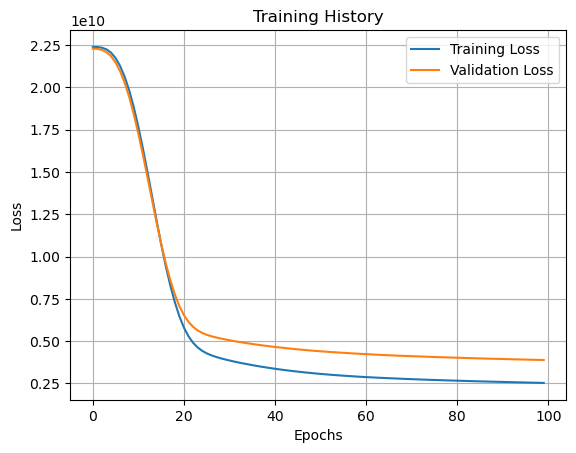

In [2]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Step 2: Load your dataset (update the path if needed)
df = pd.read_csv("ds_salaries (ML).csv")

# Step 3: Quick look at the data
print("Dataset preview:")
print(df.head())

# Step 4: Clean the data
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# Drop columns that won't help the model
if 'salary' in df.columns and 'salary_currency' in df.columns:
    df.drop(['salary', 'salary_currency'], axis=1, inplace=True)

# Step 5: Encode categorical variables
categorical_cols = ['experience_level', 'employment_type', 'job_title',
                    'employee_residence', 'company_location', 'company_size']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Step 6: Define features and target
X = df.drop('salary_in_usd', axis=1)
y = df['salary_in_usd']

# 📏 Step 7: Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 8: Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Step 9: Build the ANN model
model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer for regression
])

# Step 10: Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Step 11: Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=1)

# Step 12: Predict and evaluate
y_pred = model.predict(X_test).flatten()
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n Model Evaluation:")
print(f" RMSE: {rmse:.2f}")
print(f" R² Score: {r2:.2f}")

# Step 13: Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()